In [1]:
import re
import string
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import numpy as np

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


def ensure_stopwords_downloaded():
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords")


ensure_stopwords_downloaded()

### Tâche 1 : Chargement et Exploration du Dataset

1. **Téléchargez le dataset** :

In [2]:
url = "https://raw.githubusercontent.com/mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv"
df = (
    pd.read_csv(url, encoding="latin1")
    .drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
    .rename(columns={"v1": "label", "v2": "message"})
)

2. **Explorez les données** :
   - Affichez les 10 premières lignes avec `df.head(10)`
   - Calculez la distribution des classes : `df['label'].value_counts()`
   - Calculez le pourcentage de spam vs ham
   - Mesurez la longueur moyenne des SMS (nombre de caractères) par classe

In [3]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


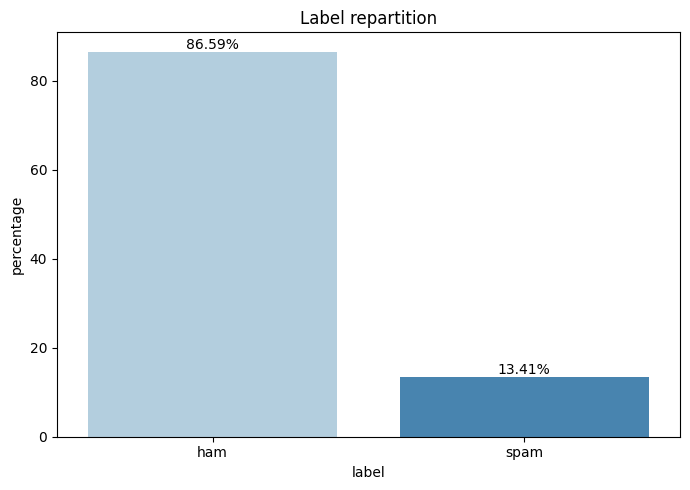

In [4]:
labels = df["label"].value_counts()
labels_percentage = labels / labels.sum() * 100

plt.figure(figsize=(7, 5))

barplot = sns.barplot(
    x=labels_percentage.index,
    y=labels_percentage.values,
    palette="Blues",
    hue=labels_percentage.index,
    legend=False,
)
for container in barplot.containers:
    barplot.bar_label(container, fmt="%.2f%%")
plt.xlabel("label")
plt.ylabel("percentage")
plt.title("Label repartition")

plt.tight_layout()
plt.show()

In [5]:
df["length"] = df["message"].apply(lambda x: sum([len(w) for w in str(x).split()]))

print(
    f"Mean length message: {df['length'].mean():.0f} (+/- {df['length'].std():.0f}) characters"
)
print(
    f"Mean length message label 'ham': {df[df['label'] == 'ham']['length'].mean():.0f} (+/- {df[df['label'] == 'ham']['length'].std():.0f}) characters"
)
print(
    f"Mean length message label 'spam': {df[df['label'] == 'spam']['length'].mean():.0f} (+/- {df[df['label'] == 'spam']['length'].std():.0f}) characters"
)

Mean length message: 66 (+/- 49) characters
Mean length message label 'ham': 58 (+/- 47) characters
Mean length message label 'spam': 116 (+/- 24) characters


3. **Visualisez des exemples** :
   - Affichez 5 exemples de spam
   - Affichez 5 exemples de ham
   - Créez un graphique de distribution de la longueur des messages

In [6]:
print("5 'ham' messages:")
for message in df[df["label"] == "ham"]["message"][:5]:
    print(f"  {message}")

print("\n5 'spam' messages:")
for message in df[df["label"] == "spam"]["message"][:5]:
    print(f"  {message}")

5 'ham' messages:
  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  Ok lar... Joking wif u oni...
  U dun say so early hor... U c already then say...
  Nah I don't think he goes to usf, he lives around here though
  Even my brother is not like to speak with me. They treat me like aids patent.

5 'spam' messages:
  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv
  WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.
  Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002

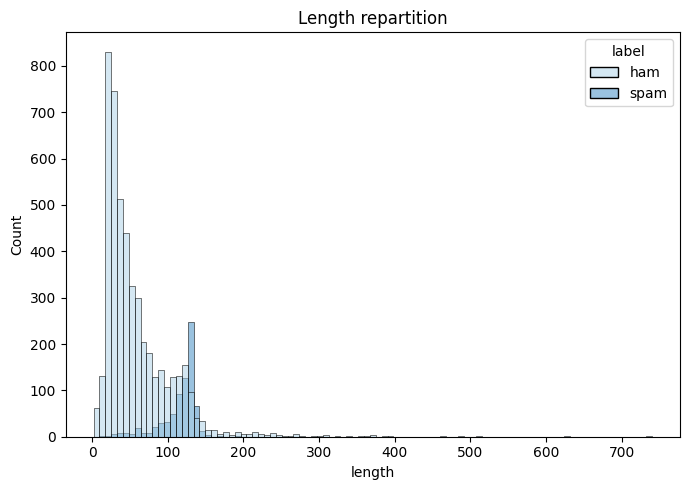

In [7]:
plt.figure(figsize=(7, 5))

sns.histplot(
    data=df,
    x="length",
    palette="Blues",
    hue="label",
    legend=True,
)
plt.title("Length repartition")

plt.tight_layout()
plt.show()

### Tâche 2 : Préparation des Données Textuelles

1. **Nettoyage du texte** (optionnel mais recommandé) :
2. **Encodage des labels** :
3. **Vectorisation du texte** avec **TF-IDF** (Term Frequency-Inverse Document Frequency)
4. **Split train/test** : avec scikit-learn
5. **One-hot encoding des labels** pour Keras :

In [8]:
STOPWORDS_EN = set(stopwords.words("english"))


def clean_message(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.encode("utf-8", "ignore").decode("utf-8")
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[\u200B-\u200D\uFEFF]", "", text)
    text = text.lower()
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = [w for w in text.split() if w not in STOPWORDS_EN]
    text = " ".join(words)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_message(text: str) -> list[str]:
    return word_tokenize(text)


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    # df["message_cleaned"] = df["message"].apply(clean_message)
    df["message_cleaned"] = df["message"].apply(
        lambda text: text.encode("utf-8", "ignore").decode("utf-8")
    )
    df["message_tokenized"] = df["message_cleaned"].apply(tokenize_message)
    return df


df = preprocess(df)
df.head()

,label,message,length,message_cleaned,message_tokenized
0,ham,"Go until jurong point, crazy.. Available only ...",92,"Go until jurong point, crazy.. Available only ...","[Go, until, jurong, point, ,, crazy, .., Avail..."
1,ham,Ok lar... Joking wif u oni...,24,Ok lar... Joking wif u oni...,"[Ok, lar, ..., Joking, wif, u, oni, ...]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,128,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F..."
3,ham,U dun say so early hor... U c already then say...,39,U dun say so early hor... U c already then say...,"[U, dun, say, so, early, hor, ..., U, c, alrea..."
4,ham,"Nah I don't think he goes to usf, he lives aro...",49,"Nah I don't think he goes to usf, he lives aro...","[Nah, I, do, n't, think, he, goes, to, usf, ,,..."


In [9]:
counter = Counter(df["message_cleaned"].str.cat(sep=" ").split())
print(f"Number of words: {len(counter.keys())}")

Number of words: 15585


In [10]:
MAX_FEATURES = 5_000

tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
)

X = tfidf.fit_transform(df["message_cleaned"])

encoder = LabelEncoder()
y = encoder.fit_transform(df["label"])
y = pd.Series(y)

print(f"X shape: {X.shape}")

X shape: (5572, 5000)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
labels_train = y_train.value_counts() / len(y_train) * 100
print("Label train set repartition:")
print(f"  ham: {labels_train[0]}")
print(f"  spam: {labels_train[1]}")
labels_test = y_test.value_counts() / len(y_test) * 100
print("Label test set repartition:")
print(f"  ham: {labels_test[0]}")
print(f"  spam: {labels_test[1]}")

Train set shape: (4457, 5000)
Test set shape: (1115, 5000)
Label train set repartition:
  ham: 86.58290329818263
  spam: 13.417096701817366
Label test set repartition:
  ham: 86.63677130044843
  spam: 13.363228699551568


In [12]:
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=2)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=2)

print("Labels encoded:")
for label in np.unique(y_train):
    idx = np.where(y_train == label)[0][0]
    print(f"{label} ---> {y_train_onehot[idx]}")

Labels encoded:
0 ---> [1. 0.]
1 ---> [0. 1.]


### Tâche 3 : Construction du MLP pour Classification Binaire

**Ce que vous devez faire :**

1. **Construisez un MLP** adapté à la classification spam/ham :
2. **Compilez le modèle**

- **Input : 1000** (nombre de features TF-IDF)
- **Hidden layers : 64 → 32** (réduction progressive)
- **Dropout : 0.3, 0.2** (régularisation contre l'overfitting)
- **Output : 2 (softmax)** (spam ou ham)

In [30]:
METRIC = "accuracy"


def create_model():
    model = keras.Sequential(
        [
            layers.Input(shape=(MAX_FEATURES,), name="input"),
            layers.Dense(128, activation="relu", name="hidden_1"),
            layers.Dropout(0.3),
            layers.Dense(64, activation="relu", name="hidden_2"),
            layers.Dropout(0.2),
            layers.Dense(32, activation="relu", name="hidden_3"),
            layers.Dense(2, activation="tanh", name="output"),
        ],
        name="MLP_MNIST",
    )

    model.compile(
        optimizer="sgd",
        loss="binary_crossentropy",
        metrics=[METRIC],
    )

    return model


model = create_model()
model.summary()

Model: "MLP_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,530 (2.48 MB)

 Trainable params: 650,530 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.array([0, 1]), y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("Poids des classes:")
print(f"  0 ---> {class_weight_dict[0]:.2f}")
print(f"  1 ---> {class_weight_dict[1]:.2f}")

Poids des classes:
  0 ---> 0.58
  1 ---> 3.73


### Tâche 4 : Entraînement avec Gestion du Déséquilibre

1. **Calculez les poids de classe** pour compenser le déséquilibre :
2. **Entraînez le modèle** avec callbacks :
3. **Visualisez les courbes d'apprentissage** :

In [32]:
def create_early_stopping():
    return EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )


def create_reduce_lr():
    return ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    )


history = model.fit(
    X_train,
    y_train_onehot,
    epochs=11,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)

Epoch 1/11
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7719 - loss: 0.7081 - val_accuracy: 0.8419 - val_loss: 0.6606 - learning_rate: 0.0100
Epoch 2/11
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7439 - loss: 0.6731 - val_accuracy: 0.8442 - val_loss: 0.6467 - learning_rate: 0.0100
Epoch 3/11
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7663 - loss: 0.6654 - val_accuracy: 0.8531 - val_loss: 0.6341 - learning_rate: 0.0100
Epoch 4/11
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7742 - loss: 0.6545 - val_accuracy: 0.9002 - val_loss: 0.6250 - learning_rate: 0.0100
Epoch 5/11
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8230 - loss: 0.6349 - val_accuracy: 0.9305 - val_loss: 0.5990 - learning_rate: 0.0100
Epoch 6/11
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8564 - loss: 0.6037 - val_accuracy: 0.9529 - val_loss: 0.5671 - learning_rate: 0.0100
Epoch 7/11
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8752 - loss: 0.5581 - 

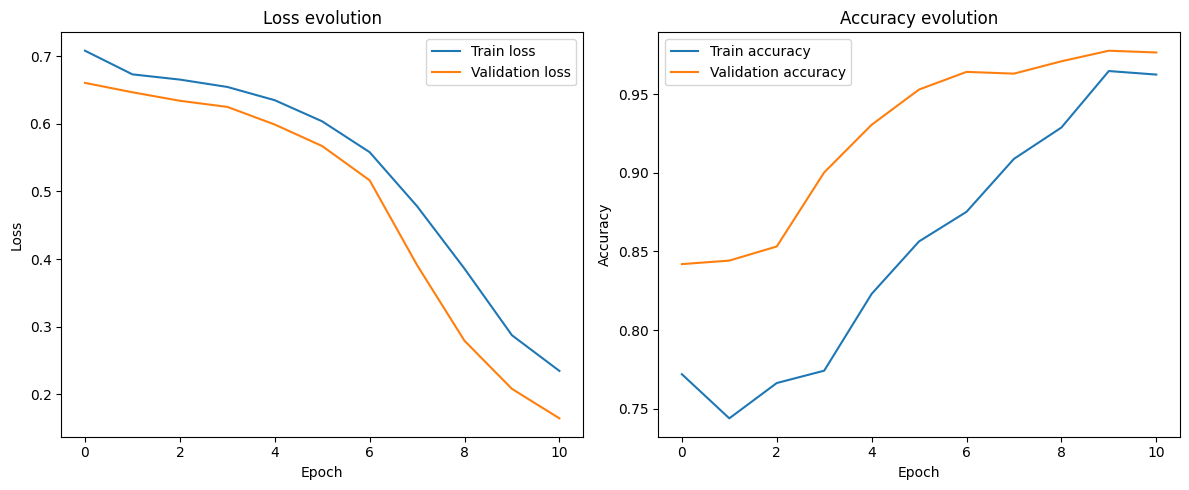

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax1.plot(history.history["loss"], label="Train loss")
ax1.plot(history.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Accuracy
ax2.plot(history.history[METRIC], label=f"Train {METRIC}")
ax2.plot(history.history[f"val_{METRIC}"], label=f"Validation {METRIC}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy evolution")
ax2.legend()

plt.tight_layout()
plt.show()

### Tâche 5 : Évaluation Détaillée

**Ce que vous devez faire :**

1. **Évaluez sur le test set**
2. **Calculez les métriques avancées** avec scikit-learn :
3. **Visualisez la matrice de confusion** :
4. **Analysez les erreurs**

**Métriques importantes :**

- **Accuracy** : % de prédictions correctes (peut être trompeur si dataset déséquilibré!)
- **Precision (spam)** : parmi les SMS prédits spam, combien sont vraiment spam ?
- **Recall (spam)** : parmi les vrais spam, combien avons-nous détectés ?
- **F1-score** : moyenne harmonique de precision/recall

In [34]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_onehot, verbose=1)

print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9794 - loss: 0.1502 
Test loss: 0.15023857355117798
Test accuracy: 0.9793722033500671


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.97      0.87      0.92       149

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



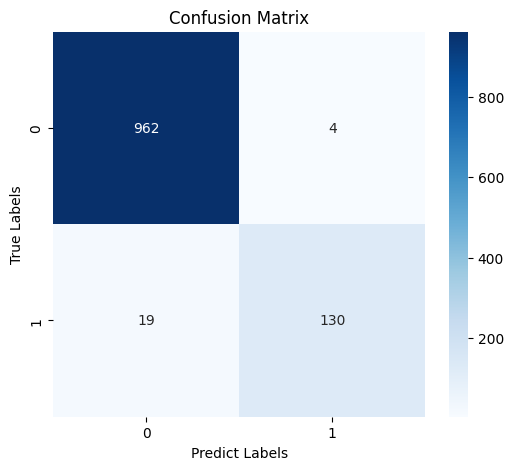

In [35]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

print(classification_report(y_test, predicted_classes))

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predict Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

### Tâche 6 : Tester le Modèle sur de Nouveaux SMS

In [36]:
new_messages = [
    "Hey are we still meeting for dinner tonight?",
    "URGENT! You have won a $1000 Walmart gift card. Click here now!",
    "Can you send me the report when you have time?",
    "Congratulations! You have been selected for a free vacation. Call now!",
    "Don't forget to bring milk on your way home",
    "You have won a prize! Claim it now at http://free-prize.com",
    "I'll call you later, I'm in a meeting right now",
    "WINNER!! Click the link to receive your cash reward today",
    "Are you coming to the party tomorrow?",
    "Limited time offer!!! Buy now and get 50% discount",
]

new_labels = [
    "ham",
    "spam",
    "ham",
    "spam",
    "ham",
    "spam",
    "ham",
    "spam",
    "ham",
    "spam",
]


def predict_spam(model, messages: list[str]) -> list[str]:
    messages_cleaned = [clean_message(message) for message in messages]
    X = tfidf.transform(messages_cleaned)
    predictions = model.predict(X)
    return np.argmax(predictions, axis=1)


new_predictions = predict_spam(model, new_messages)
label_map = {0: "ham", 1: "spam"}

print(f"{'Message':<80} | {'True Label':<20} | {'Predict Label':<20}")
print("-" * 120)
for message, label, prediction in zip(new_messages, new_labels, new_predictions):
    print(f"{message:<80} | {label:<20} | {label_map[prediction]:<20}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Message                                                                          | True Label           | Predict Label       
------------------------------------------------------------------------------------------------------------------------
Hey are we still meeting for dinner tonight?                                     | ham                  | ham                 
URGENT! You have won a $1000 Walmart gift card. Click here now!                  | spam                 | ham                 
Can you send me the report when you have time?                                   | ham                  | ham                 
Congratulations! You have been selected for a free vacation. Call now!           | spam                 | spam                
Don't forget to bring milk on your way home                                      | ham                  | ham                 
You have won a prize! Claim it now at http://free-prize.com                    

### Tâche 7 : Amélioration du Modèle (Bonus)

**Pistes d'amélioration :**

1. **Augmenter max_features du TF-IDF** :
   - Testez 2000, 3000 features au lieu de 1000

2. **Tester différentes architectures**

3. **Optimiser le seuil de décision** :
   - Au lieu de 0.5, testez 0.3 ou 0.7 pour la classification spam